# Cuentas Nacionales Trimestrales — tres mediciones de un mismo PIB

**Una oficina estadística mide el PIB de tres maneras distintas, a partir de
tres sistemas de fuentes distintos. ¿Qué se hace cuando no coinciden?**

Descargar un panel de cuentas nacionales es la parte fácil. El trabajo viene
después de la descarga, y es donde un cuaderno suele empezar a improvisar: los
volúmenes de cada país están referenciados a años base distintos y no son
comparables como niveles; la identidad contable cierra exactamente a precios
corrientes pero falla visiblemente en términos de volumen; y el crecimiento
del PIB real no se puede sumar a partir de sus componentes. Este cuaderno
recorre las cuatro transformaciones que `puremacro.fetch` ofrece para ese
trabajo — `qna_countries`, `qna_rebase`, `qna_identity`, `qna_contributions` —
sobre un panel congelado de seis países con los tres enfoques. Todo lo de
abajo corre sin red.

## El método en matemáticas

**Los tres enfoques.** La misma cantidad, medida de tres formas:

$$ Y = \underbrace{C + G + I + X - M}_{\text{gasto}}
     = \underbrace{\textstyle\sum_j VA_j + (D21 - D31) + YA1}_{\text{producción}}
     = \underbrace{D1 + B2A3G + (D2 - D3)}_{\text{ingreso}} $$

El enfoque del gasto suma quién compró el producto; el de la producción suma
el valor agregado de las industrias que lo hicieron, más impuestos netos de
subsidios sobre los productos; el del ingreso suma lo que se pagó a los
factores que lo produjeron — remuneración de asalariados $D1$, excedente bruto
de explotación e ingreso mixto $B2A3G$, e impuestos netos de subsidios sobre
la producción y las importaciones.

**Por qué los residuos no son todos lo mismo.** A *precios corrientes* la
identidad del gasto es un hecho contable, y la mayoría de las oficinas fuerza
su residuo a cero. Lo que queda es una **discrepancia estadística** — y sobre
datos desestacionalizados también carga la no aditividad que introduce ajustar
cada serie por separado, que aparece como un residuo de signo alternante y no
como una deriva.

En términos de *volumen* la identidad genuinamente no se cumple. Los volúmenes
encadenados son una cadena de Laspeyres: el crecimiento de cada trimestre usa
los precios del periodo anterior, así que los niveles no son aditivos lejos
del año de referencia y la brecha se ensancha conforme uno se aleja de él. Eso
no es un error de los datos. Es la razón por la que el crecimiento se
**descompone** en lugar de sumarse:

$$ g_t = \sum_i \omega_{i,t-1}\, g_{i,t}, \qquad
   \omega_{i,t-1} = \frac{P_{i,t-1} Q_{i,t-1}}{P_{t-1} Q_{t-1}} $$

— la ponderación es la participación del componente a **precios corrientes del
periodo anterior**, por lo cual un cálculo de contribuciones necesita el panel
nominal y el de volumen al mismo tiempo. Las importaciones entran con signo
negativo.

**Por qué cada identidad debe puntuarse dentro de su propio flujo.** La OCDE
publica el PIB por separado en cada uno de los tres flujos de datos, desde
tablas fuente distintas, y las tres cifras no siempre coinciden. Puntuar los
componentes de producción contra el PIB del flujo *del gasto* le cargaría ese
desacuerdo a los componentes. Por eso `gdp_output` y `gdp_income` se llevan
como columnas propias, cada identidad se puntúa contra la suya, y el
desacuerdo entre flujos se reporta aparte como `crossflow_output` /
`crossflow_income`.

## Preparación — un panel congelado de seis países con los tres enfoques

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.fetch import qna_contributions, qna_identity, qna_rebase
from puremacro.replication._data import load_csv

# Congelado por `tools/gen_notebook_data_qna40.py` a partir de
# `qna_panel(..., output=True, income=True, real=True)`. Un panel en vivo y uno
# congelado se comportan igual aquí: ninguna transformación toca la red.
flat = load_csv("qna40_panel")
panel = (flat.assign(date=pd.to_datetime(flat["date"]))
             .set_index(["code", "date"])
             .sort_index())

# qna_meta() lee panel.attrs, que ningún CSV puede transportar, así que la
# procedencia viaja en su propio archivo congelado.
meta = load_csv("qna40_meta")

print(f"panel: {panel.shape[0]} trimestres x {panel.shape[1]} columnas")
print(f"países: {', '.join(sorted(panel.index.get_level_values('code').unique()))}")
print(meta[["code", "currency", "price_base", "price_ref_year", "n_obs"]].to_string(index=False))

panel: 756 trimestres x 75 columnas
países: DEU, ESP, ITA, JPN, MEX, USA
code currency price_base  price_ref_year  n_obs
 DEU      EUR          L          2020.0    126
 ESP      EUR          L          2020.0    126
 ITA      EUR          L          2020.0    125
 JPN      JPY          L          2020.0    126
 MEX      MXN          Q          2018.0    125
 USA      USD          L          2017.0    126


**Lea la columna `price_ref_year`.** Los volúmenes de cada país están
referenciados al año base *de ese país* — la OCDE no impone uno común. Las
columnas de deflactor son, por lo tanto, *índices contra años distintos*, y
compararlas entre países como niveles no compara nada.

## Un solo año de referencia de precios — `qna_rebase`

`qna_rebase` pone a todos los países en un año de referencia escalando el
deflactor de cada país y reescalando sus volúmenes por el mismo factor, de
modo que `nominal = real x deflactor / 100` sigue cumpliéndose exactamente,
componente por componente. Esto es un **re-referenciamiento**: un escalar por
país, que deja intactas todas las tasas de crecimiento y todos los eslabones
de la cadena. No es un cambio de año base, que un volumen encadenado ya
publicado no permite hacer.

In [2]:
rebased = qna_rebase(panel, 2020)

q = "2020-01-01"
before = panel.xs(q, level="date")["gdp_defl"]
after = rebased.xs(q, level="date")["gdp_defl"]
comparison = pd.DataFrame({
    "año base": meta.set_index("code")["price_ref_year"].astype(int),
    "deflactor en 2020T1, publicado": before,
    "tras qna_rebase(2020)": after,
})
print(comparison.to_string(float_format=lambda v: f"{v:8.2f}"))

# La identidad sobrevive a la transformación, que es el punto de hacerla así.
resid = (rebased["gdp"] - rebased["gdp_real"] * rebased["gdp_defl"] / 100).abs()
rel = (resid / rebased["gdp"]).groupby(level="code").max()
print("\nmáx |nominal - real x deflactor/100| / nominal, tras el re-referenciamiento:")
print(rel.to_string(float_format=lambda v: f"{v:.2e}"))

      año base  deflactor en 2020T1, publicado  tras qna_rebase(2020)
code                                                                 
DEU       2020                           99.84                  99.83
ESP       2020                           99.74                  99.75
ITA       2020                           98.99                  98.98
JPN       2020                           99.72                  99.75
MEX       2018                          107.94                  98.86
USA       2017                          105.03                  99.69

máx |nominal - real x deflactor/100| / nominal, tras el re-referenciamiento:
code
DEU   5.97e-06
ESP   4.67e-06
ITA   5.21e-06
JPN   1.06e-05
MEX   4.57e-06
USA   4.37e-06


**Leyendo el resultado.** Los países ya referenciados a 2020 casi no se
mueven; los dos que no lo estaban — aquellos cuyo deflactor publicado en
2020T1 está lejos de 100 — quedan alineados al año común. La columna de
residuos confirma que la identidad contable sigue cumpliéndose después, hasta
la precisión de las seis cifras significativas del panel congelado.

## Puntuando las identidades — `qna_identity`

Cada enfoque se puntúa contra el PIB de **su propio** flujo, y los residuos se
reportan por separado en vez de netearse en un solo número.

In [3]:
ident = qna_identity(panel)
columns = ["nominal_absmax", "real_last", "output_absmax", "crossflow_output",
           "income_absmax", "crossflow_income"]
print("todas las cifras son porcentaje del PIB\n")
print(ident[columns].to_string(float_format=lambda v: f"{v:8.4f}"))

todas las cifras son porcentaje del PIB

      nominal_absmax  real_last  output_absmax  crossflow_output  income_absmax  crossflow_income
code                                                                                             
DEU           1.5124     1.2216         1.5120            0.0000         0.0005            1.7664
ESP           0.0000     0.1575         0.0000            0.0000         0.0000            0.0000
ITA           0.0004     0.0554         0.0003            0.0000         0.0005            0.0000
JPN           0.0005     0.3293         0.0006            0.6120            NaN            0.0000
MEX           5.3584     3.8951         0.0006            2.6175         0.0003            2.5144
USA           0.0004     0.0327            NaN               NaN         1.9980            0.0000


**Leyendo el resultado.** En esa tabla se ven cuatro cosas distintas, y solo
una de ellas es un problema de datos:

- **`nominal_absmax`** es la discrepancia estadística a precios corrientes.
  Donde es exactamente cero, la oficina la forzó a cero — una decisión de
  presentación, no una mejor medición. Donde no lo es, la desestacionalización
  explica buena parte: ajustar cada serie por separado hace que los
  componentes ajustados ya no sumen el total ajustado.
- **`real_last`** es la brecha de encadenamiento en el trimestre más reciente.
  No es un error y no se reduce con mejores datos; crece con la distancia al
  año de referencia, y por eso la sección de abajo descompone el crecimiento
  en lugar de sumar volúmenes.
- **`crossflow_output` / `crossflow_income`** son los desacuerdos *entre*
  flujos — el PIB del mismo país, medido de dos formas, desde dos sistemas de
  fuentes. Cargárselo a los componentes de un enfoque sería un error, así que
  tiene su propia columna.
- **Un `NaN` significa que el país no publica ese enfoque**, que es distinto
  de publicarlo con un residuo grande. Estados Unidos está ausente por
  completo del flujo de producción por actividad de la OCDE: sus cuentas por
  industria son una publicación aparte del BEA.

El `income_absmax` de Estados Unidos es el residuo que tiene nombre y
literatura propia: la **discrepancia estadística PIB–IIB**, que Nalewaik
(2010) muestra que es informativa sobre el ciclo económico por derecho propio,
y no ruido que convenga promediar.

## Figura principal — contribuciones al crecimiento del PIB real

`qna_contributions` descompone el crecimiento del PIB real en contribuciones
por componente usando ponderaciones nominales del periodo anterior: el cálculo
que el encadenamiento exige, y uno que necesita los tres productos de un panel
a la vez — volúmenes para la tasa de crecimiento, precios corrientes para la
ponderación. Lo que las ponderaciones no alcanzan a explicar se devuelve como
una columna `residual` explícita, en lugar de repartirse entre los
componentes.

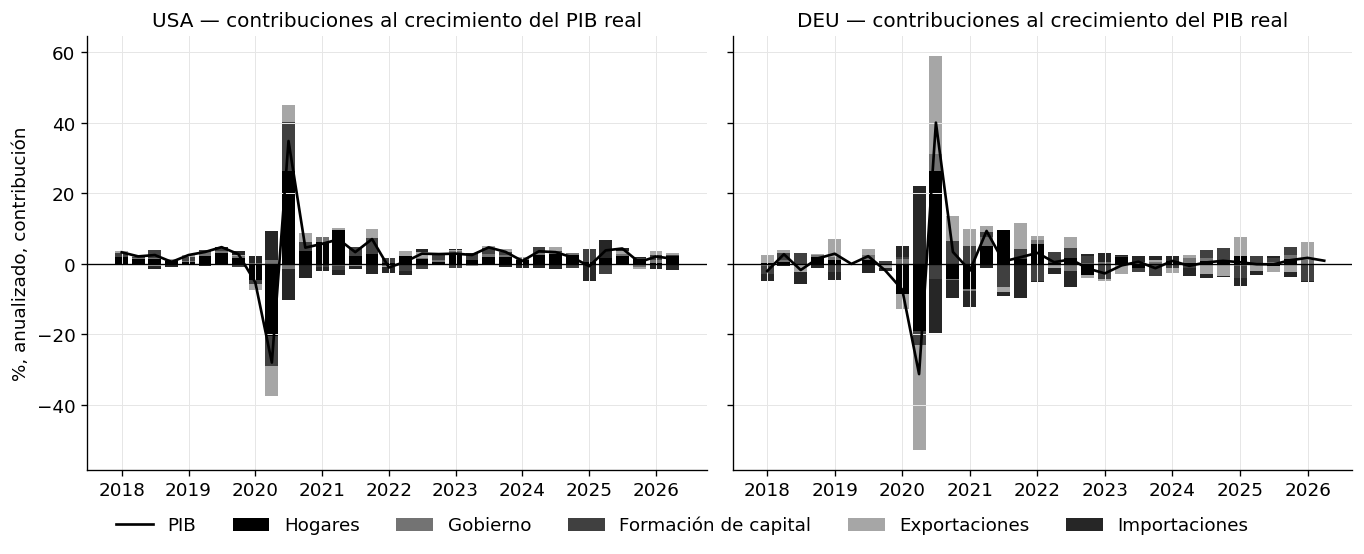

Estados Unidos, últimos cuatro trimestres (%, anualizado):
            cons_hh  cons_gov  capform  exports  imports     gdp  residual
date                                                                      
2025-07-01     2.36      0.36     0.03     1.01     0.62    4.38     -0.01
2025-10-01     1.30     -0.98     0.39    -0.35     0.13    0.48     -0.01
2026-01-01     0.37      0.70     1.40     1.12    -1.50    2.09     -0.01
2026-04-01     2.13     -0.11     0.51     0.49    -1.51    1.50     -0.01


In [4]:
contrib = qna_contributions(panel, annualise=True)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharey=True)
parts = ["cons_hh", "cons_gov", "capform", "exports", "imports"]
labels = ["Hogares", "Gobierno", "Formación de capital", "Exportaciones", "Importaciones"]
colors = _nbstyle.palette(len(parts))

for ax, code in zip(axes, ["USA", "DEU"]):
    c = contrib.loc[code].loc["2018":].dropna(how="all")
    bottom_pos = np.zeros(len(c))
    bottom_neg = np.zeros(len(c))
    for part, label, color in zip(parts, labels, colors):
        v = c[part].to_numpy()
        base = np.where(v >= 0, bottom_pos, bottom_neg)
        ax.bar(c.index, v, width=70, bottom=base, color=color,
               label=label if code == "USA" else None)
        bottom_pos = bottom_pos + np.where(v >= 0, v, 0.0)
        bottom_neg = bottom_neg + np.where(v < 0, v, 0.0)
    ax.plot(c.index, c["gdp"], color="black", lw=1.6, label="PIB" if code == "USA" else None)
    ax.axhline(0.0, color="black", lw=0.8)
    ax.set_title(f"{code} — contribuciones al crecimiento del PIB real")
    ax.set_xlabel("")

axes[0].set_ylabel("%, anualizado, contribución")
fig.legend(loc="lower center", ncol=6, frameon=False, bbox_to_anchor=(0.5, -0.06))
fig.tight_layout()
plt.show()

recent = contrib.loc["USA"].dropna(how="all").tail(4)
print("Estados Unidos, últimos cuatro trimestres (%, anualizado):")
print(recent.to_string(float_format=lambda v: f"{v:7.2f}"))

**Leyendo el resultado.** La línea negra es el crecimiento del PIB real
medido; las barras son lo que cada componente le aportó. Las importaciones
entran negativas por construcción — un trimestre en el que las importaciones
caen contribuye *positivamente* al PIB medido, lo cual es un hecho contable
sobre la identidad y no una afirmación sobre si importar menos es bueno. La
columna `residual` es la parte que las ponderaciones del periodo anterior no
abarcan; es pequeña, se reporta, y nunca se reparte entre los componentes para
que la aritmética parezca más limpia de lo que es. Las barras de 2020 muestran
los trimestres de la pandemia a tasas anualizadas, que es la convención del
comentario estadounidense y multiplica por cuatro, más o menos, la amplitud
visual de un movimiento trimestral.

## La participación del trabajo, y el adjetivo que importa

In [5]:
labour_share = (panel["comp_emp"] / panel["gdp"]).groupby(level="code").last()
print("remuneración de asalariados / PIB, trimestre más reciente:")
print(labour_share.dropna().to_string(float_format=lambda v: f"{v:.1%}"))

remuneración de asalariados / PIB, trimestre más reciente:
code
DEU   54.2%
ESP   49.2%
ITA   40.1%
JPN   49.0%
MEX   31.2%
USA   50.0%


**Esta es la participación del trabajo *sin ajustar*, y el adjetivo carga con
el peso.** La remuneración de asalariados contabiliza lo que se paga a los
*asalariados*. El ingreso de los trabajadores por cuenta propia no está en
`comp_emp` en absoluto — está dentro de `surplus_mixed`, siendo el ingreso
mixto precisamente la parte del excedente de explotación que no puede
separarse entre trabajo y capital. Así que un país con un sector de cuenta
propia grande registra un valor bajo aquí por razones que nada tienen que ver
con cómo se paga a sus asalariados. Gollin (2002) es la referencia para
ajustarlo, y la dispersión entre estos seis países es en buena medida
dispersión en el trabajo por cuenta propia, no en poder de negociación.

## Tu turno

**Ejercicios.**

1. *Básico*: re-referencie a otro año — `qna_rebase(panel, 2015)` — y verifique
   que `qna_contributions` devuelve los mismos números. Las tasas de
   crecimiento son invariantes al año de referencia; si su respuesta se mueve,
   el re-referenciamiento no fue tal.
2. *Intermedio*: puntúe la identidad sobre el panel re-referenciado en lugar
   del publicado. ¿Qué columnas de residuos cambian, y cuáles no pueden
   cambiar?
3. *Avanzado*: `qna_contributions(panel, annualise=False)` da tasas
   trimestrales en vez de anualizadas. Reconstruya la figura y compare la
   historia visual de 2020 — luego decida qué convención usaría en un artículo,
   y escriba por qué.

In [6]:
# Bloque de código de tu turno
alt = qna_rebase(panel, 2015)  # ← cambia esto: prueba 2010, 2015, 2020
same = qna_contributions(alt, annualise=True)
delta = (same["gdp"] - contrib["gdp"]).abs().max()
print(f"máx |crecimiento(re-ref. 2015) - crecimiento(publicado)|: {delta:.2e} pp")
print("El re-referenciamiento mueve niveles, nunca tasas de crecimiento.")

máx |crecimiento(re-ref. 2015) - crecimiento(publicado)|: 1.42e-13 pp
El re-referenciamiento mueve niveles, nunca tasas de crecimiento.


## ¿Qué tan completo es esto?

`qna_panel` construye el panel y `qna_countries` le pregunta al endpoint de
disponibilidad de SDMX qué áreas de referencia carga realmente un flujo — de
modo que un panel puede cubrir lo que la fuente soporta, en vez de una lista
escrita a mano que queda obsoleta. Las agrupaciones de países como `OECD` y
`EA20` se descartan por defecto, porque un panel que mezcla en silencio un
agregado con sus miembros duplica todo lo que toca.

La cobertura no es uniforme y el panel lo dice en vez de disimularlo: de las
49 áreas de referencia de la OCDE, 46 aparecen en el flujo de producción por
actividad y 40 en el de ingreso, y cuatro de esas 46 publican valor agregado
solo en términos de volumen. Un país que no publica un enfoque registra `NaN`,
nunca una brecha espuria de 100%.

Dos de las quince columnas de valor agregado son partidas informativas y no
sumandos — `va_mfg` está dentro de `va_ind`, y `va_services` agrega siete
columnas ya listadas — así que `QNA_VA_ADDITIVE` nombra las diez que
efectivamente suman el total. Sumar todas las columnas `va_*` contaría dos
veces cerca de un tercio de la economía.